<a href="https://colab.research.google.com/github/runo313/Deep-Learning/blob/main/CNNs/ResNet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchsummary import summary
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import time

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels,kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(nn.Conv2d(in_channels, out_channels,kernel_size=1, stride=stride, bias=False),
                            nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = torch.relu(out)
        return out

In [6]:
class ResNet18(nn.Module):
    def __init__(self, eta=0.001, n_iter=100, batch_size=128, random_state=42, num_classes=10):
        super().__init__()
        self.eta = eta
        self.n_iter = n_iter
        self.batch_size = batch_size
        self.random_state = random_state
        self.num_classes = num_classes

        self.device = torch.device('cuda' if torch.cuda.is_available() else
                                   'mps' if torch.mps.is_available() else
                                   'cpu')
        print(f'Using device: {self.device}')

        self.stem= nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=64,kernel_size=3,padding=1,stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.module1= nn.Sequential(
            ResidualBlock(64,64,stride=1),
            ResidualBlock(64,64,stride=1)
        )

        self.module2= nn.Sequential(
            ResidualBlock(64,128,stride=2),
            ResidualBlock(128,128,stride=1)
        )

        self.module3= nn.Sequential(
            ResidualBlock(128,256,stride=2),
            ResidualBlock(256,256,stride=1)
        )

        self.module4= nn.Sequential(
            ResidualBlock(256,512,stride=2),
            ResidualBlock(512,512,stride=1)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(512, num_classes)

        self.train_losses_     = []
        self.train_accuracies_ = []
        self.val_losses_       = []
        self.val_accuracies_   = []

        self.to(self.device)
        print(f"ResNet-18 initialised.")

    def forward(self,x):
        x = self.stem(x)
        x = self.module1(x)
        x = self.module2(x)
        x = self.module3(x)
        x = self.module4(x)
        x = self.gap(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

    def iter_minibatch(self, X, y):
        dataset    = TensorDataset(X, y)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        return dataloader

    def _evaluate(self, X, y, criterion):
        loader = self.iter_minibatch(X, y)
        self.eval()

        running_loss = 0.0
        correct      = 0
        total        = 0

        with torch.no_grad():
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                outputs = self(X_batch)
                loss    = criterion(outputs, y_batch)

                running_loss += loss.item()
                _, predicted  = torch.max(outputs, dim=1)
                total        += y_batch.size(0)
                correct      += (predicted == y_batch).sum().item()

        avg_loss = running_loss / len(loader)
        accuracy = 100.0 * correct / total
        return avg_loss, accuracy

    def predict(self, X):
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        self.eval()
        with torch.no_grad():
            X        = X.to(self.device)
            logits   = self(X)
            _, preds = torch.max(logits, dim=1)
        return preds.cpu().numpy()
    def accuracy(self, X, y):
        if isinstance(y, torch.Tensor):
            y = y.numpy()
        preds = self.predict(X)
        return 100.0 * np.mean(preds == y)

    def fit(self, X, y, X_val, y_val):
        torch.manual_seed(self.random_state)
        start_time = time.time()
        optimizer    = optim.SGD(self.parameters(), lr=self.eta,
                                 momentum=0.9, weight_decay=1e-4)
        criterion    = nn.CrossEntropyLoss()
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.n_iter)
        train_loader = self.iter_minibatch(X, y)

        for epoch in range(self.n_iter):
            epoch_start = time.time()
            self.train()

            running_loss = 0.0
            correct      = 0
            total        = 0

            for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                optimizer.zero_grad()
                y_hat = self(X_batch)
                loss  = criterion(y_hat, y_batch)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                preds = y_hat.argmax(dim=1)
                correct+= (preds == y_batch).sum().item()
                total += y_batch.size(0)

            scheduler.step()
            epoch_time = time.time() - epoch_start
            epoch_loss = running_loss / len(train_loader)
            epoch_acc  = 100.0 * correct / total

            self.train_losses_.append(epoch_loss)
            self.train_accuracies_.append(epoch_acc)

            val_loss, val_acc = self._evaluate(X_val, y_val, criterion)
            self.val_losses_.append(val_loss)
            self.val_accuracies_.append(val_acc)
            current_lr = optimizer.param_groups[0]['lr']

            print(f'Epoch {epoch+1:>3}/{self.n_iter} | '
                  f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% |'
                  f'lr: {current_lr:.6f} |'
                  f'Time: {epoch_time:.1f}s')


        self.training_time_ = time.time() - start_time    #stop the clock
        mins = self.training_time_ // 60
        secs = self.training_time_ % 60
        print(f"\nTraining complete: {int(mins)}m {secs:.1f}s")
        return self
    def training_summary(self):
      mins = int(self.training_time_ // 60)
      secs = self.training_time_ % 60
      params = sum(p.numel() for p in self.parameters())
      print(f"Parameters:    {params:,}")
      print(f"Training time: {mins}m {secs:.1f}s")
      print(f"Best val acc:  {max(self.val_accuracies_):.2f}%")
      print(f"Final test acc: call model.accuracy(X_test, y_test)")

In [7]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=train_transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=test_transform)

# ── Split trainset → 45k train / 5k val ──────────────────────────────────────
train_size = 45000
val_size   = 5000

train_subset, val_subset = random_split(
    trainset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
def dataset_to_tensors(subset):
    """Load an entire Dataset subset into memory as tensors."""
    loader = DataLoader(subset, batch_size=len(subset), shuffle=False)
    X, y = next(iter(loader))   # one giant batch = the whole subset
    return X, y

print("Loading train tensors...")
X_train, y_train = dataset_to_tensors(train_subset)

print("Loading val tensors...")
X_val, y_val     = dataset_to_tensors(val_subset)

print("Loading test tensors...")
X_test, y_test   = dataset_to_tensors(testset)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

0.0%

100.0%


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Loading train tensors...
Loading val tensors...
Loading test tensors...
Train: torch.Size([45000, 3, 32, 32]) | Val: torch.Size([5000, 3, 32, 32]) | Test: torch.Size([10000, 3, 32, 32])


In [ ]:
model = ResNet18()
summary(model, (3, 32, 32))
model.fit(X_train,y_train,X_val,y_val)
test_acc = model.accuracy(X_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

Using device: cuda
ResNet-18 initialised.
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,864
       BatchNorm2d-5           [-1, 64, 32, 32]             128
            Conv2d-6           [-1, 64, 32, 32]          36,864
       BatchNorm2d-7           [-1, 64, 32, 32]             128
          Identity-8           [-1, 64, 32, 32]               0
     ResidualBlock-9           [-1, 64, 32, 32]               0
           Conv2d-10           [-1, 64, 32, 32]          36,864
      BatchNorm2d-11           [-1, 64, 32, 32]             128
           Conv2d-12           [-1, 64, 32, 32]          36,864
      BatchNorm2d-13           [-1, 64, 32, 32]             1

In [ ]:
def plot_curves(model, title):
  epochs = range(1, len(model.train_losses_) + 1)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  ax1.plot(epochs, model.train_losses_,
            label='Train loss',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax1.plot(epochs, model.val_losses_,
            label='Val loss',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax1.set_xlabel('Epoch', fontsize=12)
  ax1.set_ylabel('Cross-entropy loss', fontsize=12)
  ax1.set_title('Loss per epoch', fontsize=13)
  ax1.legend(fontsize=11)
  ax1.grid(True, alpha=0.3)

  ax2.plot(epochs, model.train_accuracies_,
            label='Train accuracy',
            color='steelblue',
            linewidth=1.8,
            marker='o', markersize=2)

  ax2.plot(epochs, model.val_accuracies_,
            label='Val accuracy',
            color='tomato',
            linewidth=1.8,
            linestyle='--',
            marker='o', markersize=2)

  ax2.set_xlabel('Epoch', fontsize=12)
  ax2.set_ylabel('Accuracy (%)', fontsize=12)
  ax2.set_title('Accuracy per epoch', fontsize=13)
  ax2.set_ylim(0, 100)
  ax2.legend(fontsize=11)
  ax2.grid(True, alpha=0.3)

  plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
  plt.tight_layout()
  plt.show()
  print("Saved: training_curves.png")



In [ ]:
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

def plot_confusion_matrix(model, X_test, y_test, title='Confusion Matrix — AlexNet CIFAR-10 (Part A)'):
    # Get predictions from the model
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,           # show counts in each cell
        fmt='d',              # integer format
        cmap='Blues',         # blue colormap — darker = more examples
        xticklabels=CIFAR10_CLASSES,
        yticklabels=CIFAR10_CLASSES,
        linewidths=0.5,
        linecolor='gray',
        ax=ax
    )

    ax.set_xlabel('Predicted label', fontsize=12, labelpad=10)
    ax.set_ylabel('True label', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

    # Rotate x-axis labels so they don't overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix.png")

    # ── Print per-class accuracy ───────────────────────────────────────────
    print("\nPer-class accuracy:")
    print("-" * 35)
    for i, class_name in enumerate(CIFAR10_CLASSES):
        class_total   = cm[i].sum()
        class_correct = cm[i, i]
        class_acc     = 100.0 * class_correct / class_total
        print(f"  {class_name:<12}: {class_correct:>4}/{class_total} = {class_acc:.1f}%")
    print("-" * 35)
    overall = 100.0 * np.diag(cm).sum() / cm.sum()
    print(f"  {'Overall':<12}: {overall:.2f}%")

In [ ]:
model.training_summary()

Parameters:    11,174,026
Training time: 70m 19.3s
Best val acc:  74.46%
Final test acc: call model.accuracy(X_test, y_test)


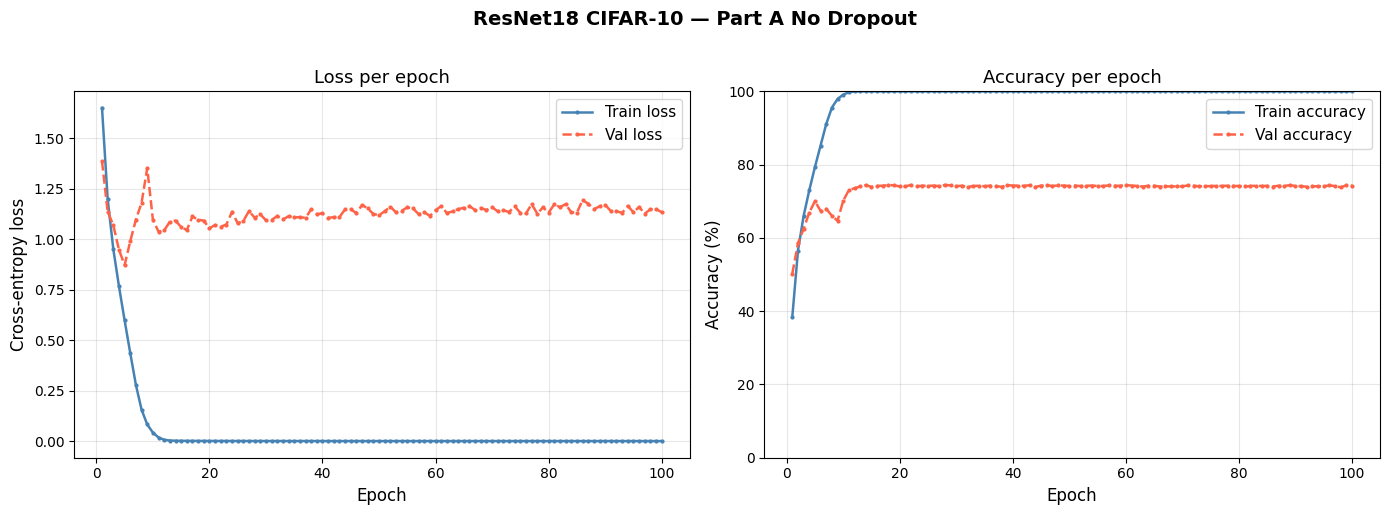

Saved: training_curves.png


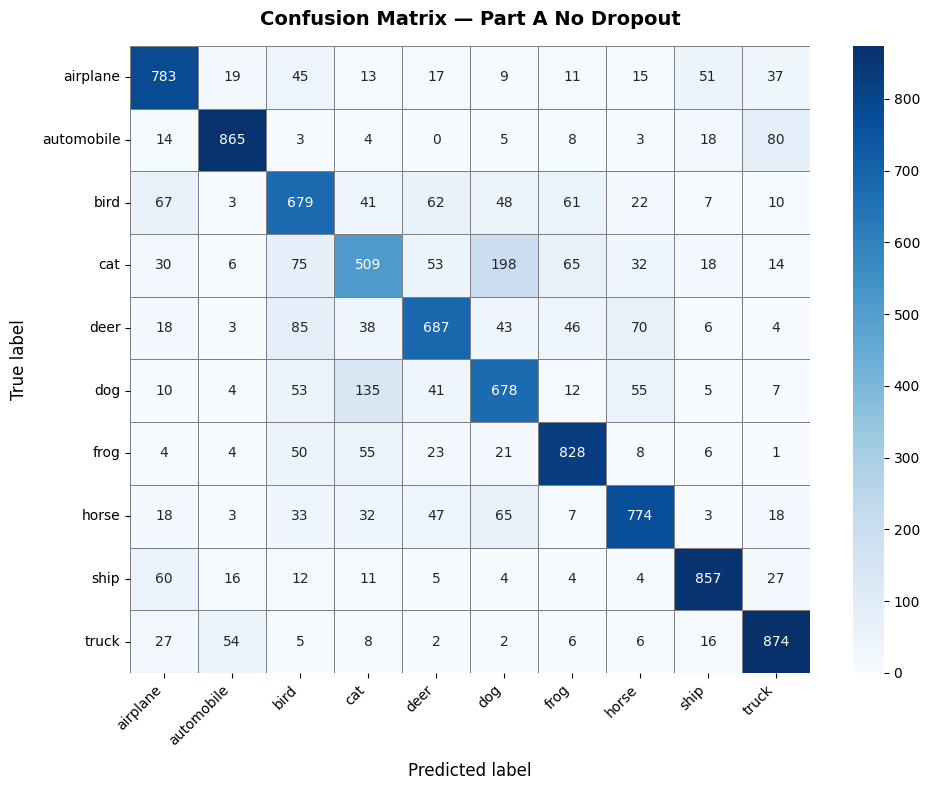

Saved: confusion_matrix.png

Per-class accuracy:
-----------------------------------
  airplane    :  783/1000 = 78.3%
  automobile  :  865/1000 = 86.5%
  bird        :  679/1000 = 67.9%
  cat         :  509/1000 = 50.9%
  deer        :  687/1000 = 68.7%
  dog         :  678/1000 = 67.8%
  frog        :  828/1000 = 82.8%
  horse       :  774/1000 = 77.4%
  ship        :  857/1000 = 85.7%
  truck       :  874/1000 = 87.4%
-----------------------------------
  Overall     : 75.34%


In [ ]:
plot_curves(model, title='ResNet18 CIFAR-10 — Part A No Dropout')

plot_confusion_matrix(model, X_test, y_test,
                      title='Confusion Matrix — Part A No Dropout')

In [10]:
class ResNet11(ResNet18):
    def __init__(self, eta=0.001, n_iter=100, batch_size=128, random_state=42, num_classes=10):
        super().__init__(eta, n_iter, batch_size, random_state, num_classes)
        self.module1 = nn.Sequential(ResidualBlock(64, 64, stride=1))
        self.module2 = nn.Sequential(ResidualBlock(64, 128, stride=2))
        self.module3 = nn.Sequential(ResidualBlock(128, 256, stride=2))
        self.module4 = nn.Sequential(ResidualBlock(256, 512, stride=2))
        self.to(self.device)
        print("ResNet-11 initialised")
    def forward(self, x):
        x = self.stem(x)
        x = self.module1(x)
        x = self.module2(x)
        x = self.module3(x)
        x = self.module4(x)
        x = self.gap(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

In [ ]:
model_1 = ResNet11()
summary(model_1, (3, 32, 32))
model_1.fit(X_train,y_train,X_val,y_val)
test_acc = model_1.accuracy(X_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

Using device: cuda
ResNet-18 initialised.
ResNet-11 initialised
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,864
       BatchNorm2d-5           [-1, 64, 32, 32]             128
            Conv2d-6           [-1, 64, 32, 32]          36,864
       BatchNorm2d-7           [-1, 64, 32, 32]             128
          Identity-8           [-1, 64, 32, 32]               0
     ResidualBlock-9           [-1, 64, 32, 32]               0
           Conv2d-10          [-1, 128, 16, 16]          73,728
      BatchNorm2d-11          [-1, 128, 16, 16]             256
           Conv2d-12          [-1, 128, 16, 16]         147,456
      BatchNorm2d-13          [-1, 128,

Parameters:    4,903,306
Training time: 41m 31.4s
Best val acc:  72.90%
Final test acc: call model.accuracy(X_test, y_test)


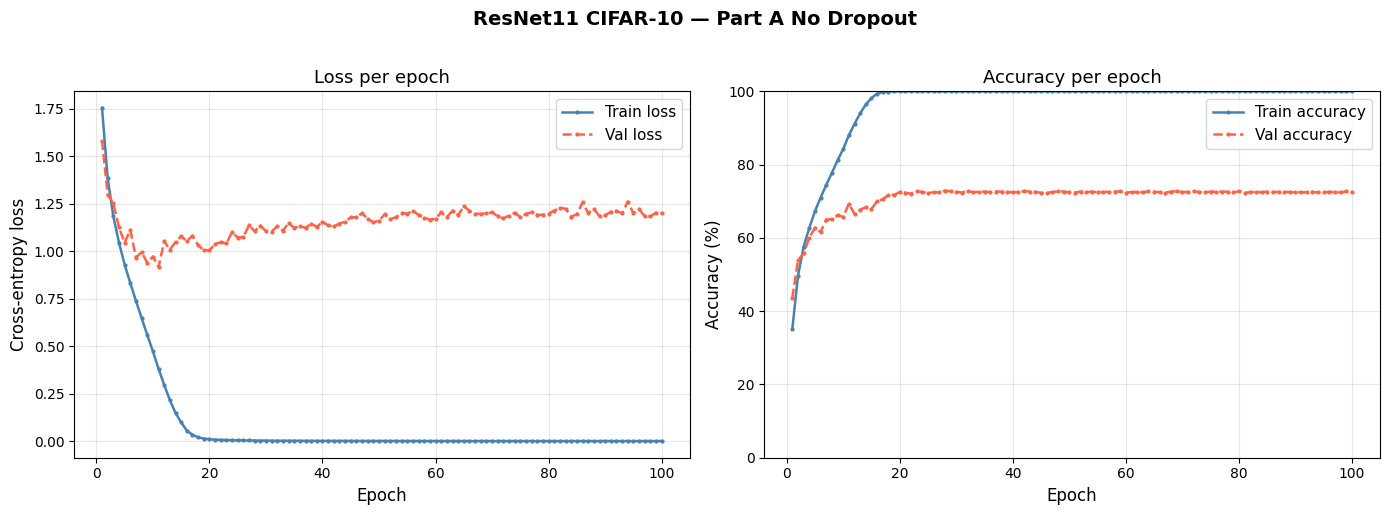

Saved: training_curves.png


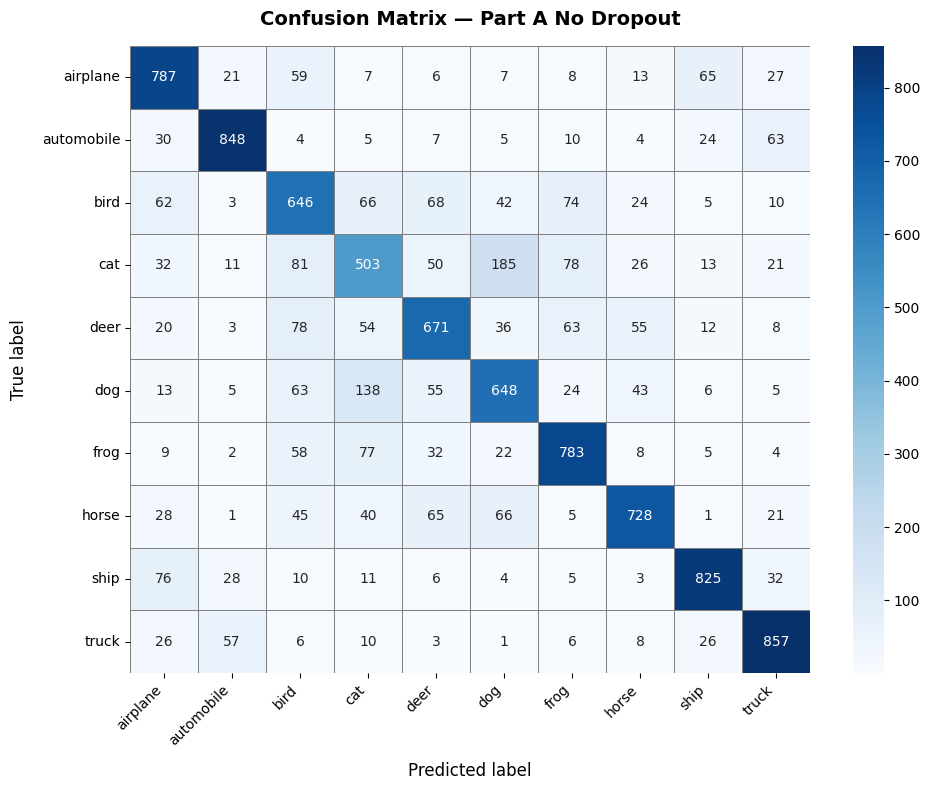

Saved: confusion_matrix.png

Per-class accuracy:
-----------------------------------
  airplane    :  787/1000 = 78.7%
  automobile  :  848/1000 = 84.8%
  bird        :  646/1000 = 64.6%
  cat         :  503/1000 = 50.3%
  deer        :  671/1000 = 67.1%
  dog         :  648/1000 = 64.8%
  frog        :  783/1000 = 78.3%
  horse       :  728/1000 = 72.8%
  ship        :  825/1000 = 82.5%
  truck       :  857/1000 = 85.7%
-----------------------------------
  Overall     : 72.96%


In [ ]:
model_1.training_summary()
plot_curves(model_1, title='ResNet11 CIFAR-10 — Part A No Dropout')

plot_confusion_matrix(model_1, X_test, y_test,
                      title='Confusion Matrix — Part A No Dropout')

In [11]:
class ResNet18Dropout(ResNet18):
    def __init__(self, eta=0.001, n_iter=100, batch_size=128,
                 random_state=42, num_classes=10, dropout_rate=0.5):
        super().__init__(eta, n_iter, batch_size, random_state, num_classes)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.dropout_rate = dropout_rate
        self.to(self.device)
        print(f"ResNet-18 + Dropout(p={dropout_rate}) initialised")
    def forward(self, x):
        x = self.stem(x)
        x = self.module1(x)
        x = self.module2(x)
        x = self.module3(x)
        x = self.module4(x)
        x = self.gap(x)
        x = self.flatten(x)
        x = self.dropout(x)    # ← after flatten, before FC
        x = self.fc(x)
        return x


class ResNet11Dropout(ResNet11):
    def __init__(self, eta=0.001, n_iter=100, batch_size=128,
                 random_state=42, num_classes=10, dropout_rate=0.5):
        super().__init__(eta, n_iter, batch_size, random_state, num_classes)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.dropout_rate = dropout_rate
        self.to(self.device)
        print(f"ResNet-11 + Dropout(p={dropout_rate}) initialised")
    def forward(self, x):
        x = self.stem(x)
        x = self.module1(x)
        x = self.module2(x)
        x = self.module3(x)
        x = self.module4(x)
        x = self.gap(x)
        x = self.flatten(x)
        x = self.dropout(x)    # ← after flatten, before FC
        x = self.fc(x)
        return x

In [ ]:
rn18_d3 = ResNet18Dropout(eta=0.1, n_iter=100, batch_size=128,
                           random_state=42, dropout_rate=0.3)
rn18_d3.fit(X_train, y_train, X_val, y_val)

Using device: cuda
ResNet-18 initialised.
ResNet-18 + Dropout(p=0.3) initialised
Epoch   1/100 | Loss: 2.1858 | Acc: 26.78% | Val Loss: 1.7576 | Val Acc: 37.02% |lr: 0.099975 |Time: 43.1s
Epoch   2/100 | Loss: 1.5964 | Acc: 40.89% | Val Loss: 1.4633 | Val Acc: 45.84% |lr: 0.099901 |Time: 39.2s
Epoch   3/100 | Loss: 1.3972 | Acc: 49.03% | Val Loss: 1.3522 | Val Acc: 51.18% |lr: 0.099778 |Time: 41.4s
Epoch   4/100 | Loss: 1.1991 | Acc: 56.48% | Val Loss: 1.1989 | Val Acc: 55.98% |lr: 0.099606 |Time: 40.2s
Epoch   5/100 | Loss: 1.0223 | Acc: 63.33% | Val Loss: 1.0160 | Val Acc: 64.80% |lr: 0.099384 |Time: 40.8s
Epoch   6/100 | Loss: 0.8715 | Acc: 69.17% | Val Loss: 0.9012 | Val Acc: 68.70% |lr: 0.099114 |Time: 40.9s
Epoch   7/100 | Loss: 0.7341 | Acc: 74.16% | Val Loss: 0.8343 | Val Acc: 69.96% |lr: 0.098796 |Time: 40.9s
Epoch   8/100 | Loss: 0.6162 | Acc: 78.31% | Val Loss: 0.8670 | Val Acc: 70.50% |lr: 0.098429 |Time: 40.9s
Epoch   9/100 | Loss: 0.5107 | Acc: 82.02% | Val Loss: 0.7158 |

ResNet18Dropout(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (module1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchN

In [ ]:
rn18_d5 = ResNet18Dropout(eta=0.1, n_iter=100, batch_size=128,
                           random_state=42, dropout_rate=0.5)
rn18_d5.fit(X_train, y_train, X_val, y_val)

rn18_d5.training_summary()
plot_curves(rn18_d5, title='ResNet18 CIFAR-10 — Part B  Dropout(0.5)')

plot_confusion_matrix(rn18_d5, X_test, y_test,
                      title='Confusion Matrix — Part B Dropout(0.5)')


Using device: mps
ResNet-18 initialised.
ResNet-18 + Dropout(p=0.5) initialised
Epoch   1/100 | Loss: 2.3353 | Acc: 25.52% | Val Loss: 1.8283 | Val Acc: 32.22% |lr: 0.099975 |Time: 62.7s
Epoch   2/100 | Loss: 1.6808 | Acc: 37.68% | Val Loss: 1.5975 | Val Acc: 40.68% |lr: 0.099901 |Time: 62.0s
Epoch   3/100 | Loss: 1.5169 | Acc: 44.38% | Val Loss: 1.4921 | Val Acc: 46.26% |lr: 0.099778 |Time: 64.0s
Epoch   4/100 | Loss: 1.3764 | Acc: 49.86% | Val Loss: 1.4040 | Val Acc: 48.92% |lr: 0.099606 |Time: 70.3s
Epoch   5/100 | Loss: 1.2219 | Acc: 56.00% | Val Loss: 1.2653 | Val Acc: 54.92% |lr: 0.099384 |Time: 72.0s
Epoch   6/100 | Loss: 1.0697 | Acc: 61.96% | Val Loss: 1.3657 | Val Acc: 54.74% |lr: 0.099114 |Time: 77.0s
Epoch   7/100 | Loss: 0.9365 | Acc: 66.93% | Val Loss: 0.9820 | Val Acc: 65.68% |lr: 0.098796 |Time: 68.6s
Epoch   8/100 | Loss: 0.8269 | Acc: 70.80% | Val Loss: 0.9301 | Val Acc: 67.12% |lr: 0.098429 |Time: 68.6s
Epoch   9/100 | Loss: 0.7263 | Acc: 74.35% | Val Loss: 0.9435 | 